In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy/S14/HR.csv
/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy/S14/IBI.csv
/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy/S14/BVP.csv
/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy/S14/EDA.csv
/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy/S14/TEMP.csv
/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy/S14/ACC.csv
/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy/S1/HR.csv
/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy/S1/IBI.csv
/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy/S1/BVP.csv
/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy/S1/EDA.csv
/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy/S1/TEMP.csv
/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy/S1/ACC.csv
/kaggle/input/datasets

# Imports

In [ ]:
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from scipy.stats import skew, kurtosis

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

import warnings
warnings.filterwarnings("ignore")

# Configurations

In [ ]:
DATA_ROOT = "/kaggle/input/datasets/sumanchowdhury2004/ppg-wearable/PPG_FieldStudy"
FS_BVP = 64
WINDOW = 256          
STEP = 128
EPOCHS = 100
BATCH = 64
LR = 1e-4
N_SPLITS = 5
SEED = 42
PATIENCE = 15
WEIGHT_DECAY = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Reproducibility Function

In [4]:
def set_seed(seed):
    np.random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Feature Extraction

In [5]:
def bvp_features(sig):
    feats = [
        np.mean(sig),
        np.std(sig),
        skew(sig),
        kurtosis(sig)
    ]
    peaks, _ = find_peaks(sig, distance=FS_BVP*0.4)
    feats.append(len(peaks))
    feats.append(np.mean(np.diff(peaks)) if len(peaks) > 1 else 0)
    return feats

def acc_features(acc):
    acc = acc.reshape(-1, 3)
    mag = np.linalg.norm(acc, axis=1)
    return [
        np.mean(mag),
        np.std(mag),
        np.sum(mag**2) / len(mag)
    ]

def eda_features(sig):
    return [
        np.mean(sig),
        np.std(sig),
        np.polyfit(np.arange(len(sig)), sig, 1)[0]
    ]

def temp_features(sig):
    return [
        np.mean(sig),
        np.std(sig)
    ]

def compute_hr_from_bvp(sig):
    peaks, _ = find_peaks(sig, distance=FS_BVP*0.4)
    if len(peaks) < 2:
        return None
    ibi = np.diff(peaks) / FS_BVP
    hr = 60 / np.mean(ibi)
    return hr

# Data Loading

In [6]:
X, y = [], []

for subj in os.listdir(DATA_ROOT):
    sp = os.path.join(DATA_ROOT, subj)
    if not os.path.isdir(sp):
        continue

    try:
        bvp = pd.read_csv(os.path.join(sp, "BVP.csv"), header=None).values.flatten()
        acc = pd.read_csv(os.path.join(sp, "ACC.csv"), header=None).values
        eda = pd.read_csv(os.path.join(sp, "EDA.csv"), header=None).values.flatten()
        temp = pd.read_csv(os.path.join(sp, "TEMP.csv"), header=None).values.flatten()
    except:
        continue

    L = min(len(bvp), len(eda), len(temp))
    acc = acc[:L//2]  

    for i in range(0, L - WINDOW, STEP):
        bvp_w = bvp[i:i+WINDOW]
        eda_w = eda[i:i+WINDOW]
        temp_w = temp[i:i+WINDOW]
        acc_w = acc[i//2:(i+WINDOW)//2]

        hr = compute_hr_from_bvp(bvp_w)
        if hr is None or hr < 40 or hr > 180:
            continue

        feats = (
            bvp_features(bvp_w) +
            acc_features(acc_w) +
            eda_features(eda_w) +
            temp_features(temp_w)
        )

        X.append(feats)
        y.append(hr)

X = np.array(X)
y = np.array(y)

print("Total samples:", X.shape)

Total samples: (4211, 14)


# Dataset Class

In [7]:
class PPGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# T-KAN Architecture
## Temporal-Kolmogorov-Arnold Network with σ = 1 / √2 (Spline Basis)

In [8]:
class SplineLayer(nn.Module):
    """KAN Spline transformation layer with residual base connection."""
    def __init__(self, in_dim, out_dim, grid_size=12):
        super().__init__()
        self.grid = nn.Parameter(
            torch.linspace(-2, 2, grid_size),
            requires_grad=False
        )
        self.coeff = nn.Parameter(
            torch.randn(out_dim, in_dim, grid_size) * 0.1
        )
        self.base_linear = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        base_out = self.base_linear(x)
        x_un = x.unsqueeze(-1)
        basis = torch.exp(-((x_un - self.grid) ** 2))
        spline_out = torch.einsum("...ig,oig->...o", basis, self.coeff)
        return base_out + spline_out

class TKANCell(nn.Module):
    """Temporal Recurrent KAN Cell replacing standard linear projections."""
    def __init__(self, in_dim, hidden_dim, grid_size=12):
        super().__init__()
        self.kan_z = SplineLayer(in_dim + hidden_dim, hidden_dim, grid_size)
        self.kan_r = SplineLayer(in_dim + hidden_dim, hidden_dim, grid_size)
        self.kan_h = SplineLayer(in_dim + hidden_dim, hidden_dim, grid_size)

    def forward(self, x, h):
        combined = torch.cat([x, h], dim=-1)
        z = torch.sigmoid(self.kan_z(combined))
        r = torch.sigmoid(self.kan_r(combined))
        
        combined_r = torch.cat([x, r * h], dim=-1)
        h_tilde = torch.tanh(self.kan_h(combined_r))
        
        h_next = (1 - z) * h + z * h_tilde
        return h_next

class TKANModel(nn.Module):
    """T-KAN Model combining Temporal KAN Recurrence and Deep KAN Readout."""
    def __init__(self, in_dim, hidden_dim=32, grid_size=12):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.tkan_cell = TKANCell(in_dim, hidden_dim, grid_size)
        
        # Readout KAN Stack
        self.kan_out1 = SplineLayer(hidden_dim, 16, grid_size)
        self.kan_out2 = SplineLayer(16, 1, grid_size)

    def forward(self, x):
        batch_size = x.size(0)
        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)
        h = self.tkan_cell(x, h)
        out = torch.relu(self.kan_out1(h))
        out = self.kan_out2(out)
        return out.squeeze(-1)


# Model Training

In [ ]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

all_mae, all_rmse, all_r2, all_mape = [], [], [], []
bland_altman_y_true = []
bland_altman_y_pred = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    print("\n" + "=" * 60)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("=" * 60)
    
    set_seed(SEED + fold)

    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    X_scaler = StandardScaler()
    X_train_scaled = X_scaler.fit_transform(X_train_fold)
    X_test_scaled = X_scaler.transform(X_test_fold)

    y_mean = y_train_fold.mean()
    y_std = y_train_fold.std()

    y_train_norm = (y_train_fold - y_mean) / y_std
    y_test_norm = (y_test_fold - y_mean) / y_std

    train_loader = DataLoader(PPGDataset(X_train_scaled, y_train_norm), batch_size=BATCH, shuffle=True)
    test_loader = DataLoader(PPGDataset(X_test_scaled, y_test_norm), batch_size=BATCH, shuffle=False)

    model = TKANModel(in_dim=X.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    # Training Loop
    for epoch in range(EPOCHS):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(loss.item())

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch + 1}/{EPOCHS} | Loss: {np.mean(losses):.6f}")

    # Evaluation
    model.eval()
    fold_preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(DEVICE)
            preds_batch = model(xb)
            fold_preds.extend(preds_batch.cpu().numpy())

    fold_preds = np.array(fold_preds)
    
    # De-normalize predictions
    fold_preds = fold_preds * y_std + y_mean
    y_true = y_test_fold

    bland_altman_y_true.extend(y_true)
    bland_altman_y_pred.extend(fold_preds)

    mae = mean_absolute_error(y_true, fold_preds)
    rmse = np.sqrt(mean_squared_error(y_true, fold_preds))
    r2 = r2_score(y_true, fold_preds)
    mape = np.mean(np.abs((y_true - fold_preds) / y_true)) * 100

    all_mae.append(mae)
    all_rmse.append(rmse)
    all_r2.append(r2)
    all_mape.append(mape)

    print(f"Fold {fold} Results -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.4f}%, R²: {r2:.4f}")



FOLD 1/5
Epoch 20/100 | Loss: 0.009687
Epoch 40/100 | Loss: 0.003090
Epoch 60/100 | Loss: 0.001146
Epoch 80/100 | Loss: 0.000458
Epoch 100/100 | Loss: 0.000262
Fold 1 Results -> MAE: 0.1207, RMSE: 0.2085, MAPE: 0.1701%, R²: 0.9999

FOLD 2/5
Epoch 20/100 | Loss: 0.003215
Epoch 40/100 | Loss: 0.001254
Epoch 60/100 | Loss: 0.000701
Epoch 80/100 | Loss: 0.000485
Epoch 100/100 | Loss: 0.000361
Fold 2 Results -> MAE: 0.1649, RMSE: 0.3433, MAPE: 0.2110%, R²: 0.9996

FOLD 3/5
Epoch 20/100 | Loss: 0.004953
Epoch 40/100 | Loss: 0.001402
Epoch 60/100 | Loss: 0.000608
Epoch 80/100 | Loss: 0.000428
Epoch 100/100 | Loss: 0.000331
Fold 3 Results -> MAE: 0.1654, RMSE: 0.2634, MAPE: 0.2248%, R²: 0.9998

FOLD 4/5
Epoch 20/100 | Loss: 0.002785
Epoch 40/100 | Loss: 0.000849
Epoch 60/100 | Loss: 0.000467
Epoch 80/100 | Loss: 0.000336
Epoch 100/100 | Loss: 0.000244
Fold 4 Results -> MAE: 0.1081, RMSE: 0.2791, MAPE: 0.1402%, R²: 0.9998

FOLD 5/5
Epoch 20/100 | Loss: 0.003868
Epoch 40/100 | Loss: 0.001315
Ep

# Final Results

In [10]:
print("\n" + "=" * 70)
print("FINAL RESULTS ACROSS 5-FOLD CROSS VALIDATION (T-KAN)")
print("=" * 70)
print(f"MAE  : {np.mean(all_mae):.4f} ± {np.std(all_mae, ddof=1):.4f} bpm")
print(f"RMSE : {np.mean(all_rmse):.4f} ± {np.std(all_rmse, ddof=1):.4f} bpm")
print(f"MAPE : {np.mean(all_mape):.4f} ± {np.std(all_mape, ddof=1):.4f}%")
print(f"R²   : {np.mean(all_r2):.6f} ± {np.std(all_r2, ddof=1):.6f}")


FINAL RESULTS ACROSS 5-FOLD CROSS VALIDATION (T-KAN)
MAE  : 0.1661 ± 0.0642 bpm
RMSE : 0.3200 ± 0.1144 bpm
MAPE : 0.2250 ± 0.0922%
R²   : 0.999651 ± 0.000254


# Bland-Altman Plot (Across all folds)

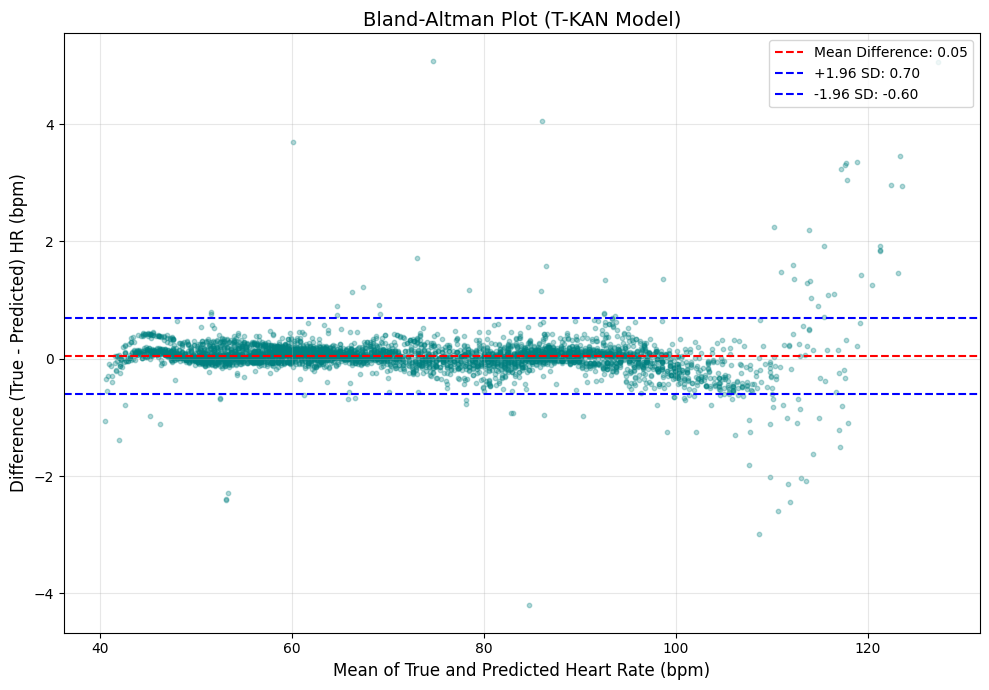

In [11]:
y_true_all = np.array(bland_altman_y_true)
y_pred_all = np.array(bland_altman_y_pred)

mean_vals = (y_true_all + y_pred_all) / 2
diff_vals = y_true_all - y_pred_all
md = np.mean(diff_vals)
sd = np.std(diff_vals, axis=0)

plt.figure(figsize=(10, 7))
plt.scatter(mean_vals, diff_vals, alpha=0.3, s=10, color='teal')
plt.axhline(md, color='red', linestyle='--', label=f'Mean Difference: {md:.2f}')
plt.axhline(md + 1.96 * sd, color='blue', linestyle='--', label=f'+1.96 SD: {md + 1.96*sd:.2f}')
plt.axhline(md - 1.96 * sd, color='blue', linestyle='--', label=f'-1.96 SD: {md - 1.96*sd:.2f}')

plt.xlabel('Mean of True and Predicted Heart Rate (bpm)', fontsize=12)
plt.ylabel('Difference (True - Predicted) HR (bpm)', fontsize=12)
plt.title('Bland-Altman Plot (T-KAN Model)', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("TKAN_bland_altman.png", dpi=600, bbox_inches="tight")
plt.show()

# Error Histogram

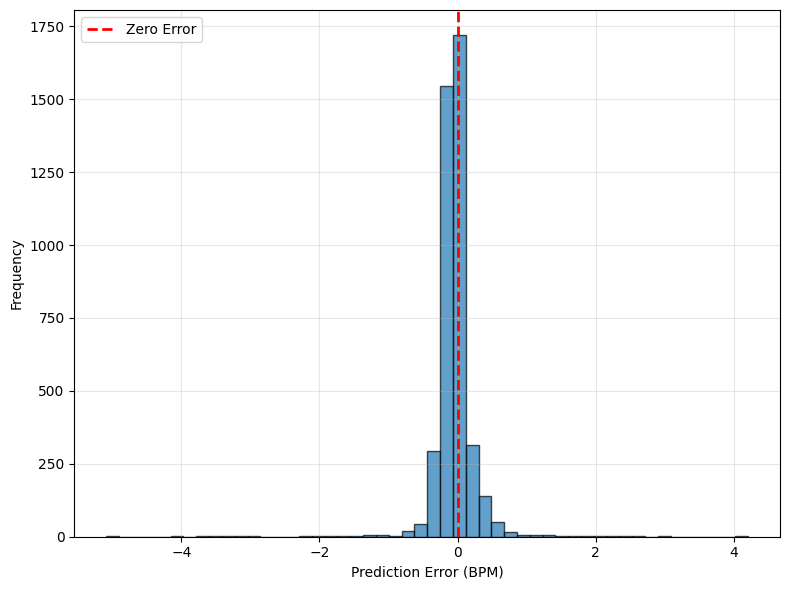

In [12]:
errors = y_pred_all - y_true_all

plt.figure(figsize=(8, 6))
# Using edgecolor to match the distinct bar outlines in the reference
plt.hist(errors, bins=50, color='tab:blue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')

plt.xlabel('Prediction Error (BPM)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("TKAN_error_histogram.png", dpi=600, bbox_inches="tight")
plt.show()

# Scatter Plot

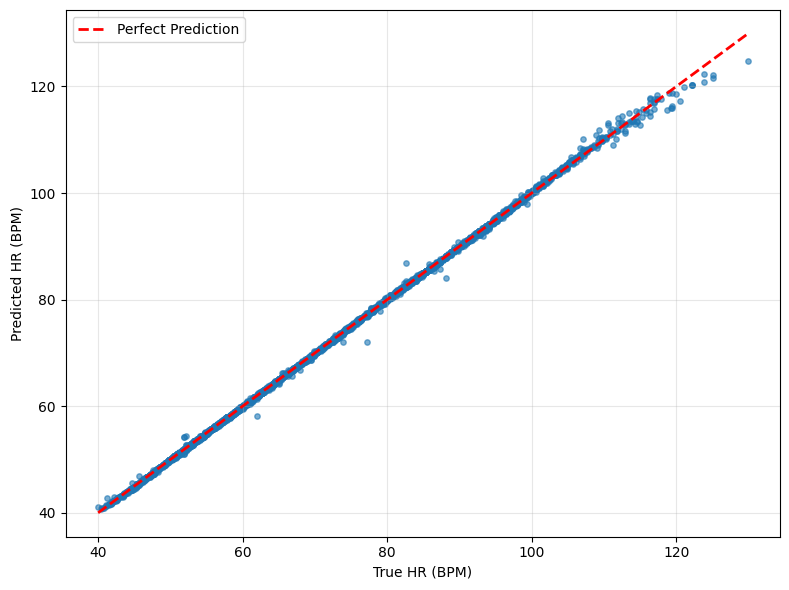

In [13]:
plt.figure(figsize=(8, 6))
# s=15 and alpha=0.6 match the point density and transparency of the reference
plt.scatter(y_true_all, y_pred_all, alpha=0.6, s=15, color='tab:blue')

# Generate the ideal "Perfect Prediction" diagonal line based on data boundaries
min_val = min(np.min(y_true_all), np.min(y_pred_all))
max_val = max(np.max(y_true_all), np.max(y_pred_all))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel('True HR (BPM)', fontsize=10)
plt.ylabel('Predicted HR (BPM)', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("TKAN_scatter_plot.png", dpi=600, bbox_inches="tight")
plt.show()

# New Training Pipeline (Weight Decay + Early Stopping)

In [ ]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

all_mae, all_rmse, all_r2, all_mape = [], [], [], []
bland_altman_y_true = []
bland_altman_y_pred = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    print("\n" + "=" * 60)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("=" * 60)

    set_seed(SEED + fold)

    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    X_scaler = StandardScaler()
    X_train_scaled = X_scaler.fit_transform(X_train_fold)
    X_test_scaled = X_scaler.transform(X_test_fold)

    y_mean = y_train_fold.mean()
    y_std = y_train_fold.std()

    y_train_norm = (y_train_fold - y_mean) / y_std
    y_test_norm = (y_test_fold - y_mean) / y_std

    train_loader = DataLoader(PPGDataset(X_train_scaled, y_train_norm), batch_size=BATCH, shuffle=True)
    test_loader = DataLoader(PPGDataset(X_test_scaled, y_test_norm), batch_size=BATCH, shuffle=False)

    model = TKANModel(in_dim=X.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.MSELoss()

    # Early Stopping state tracking
    best_val_loss = float("inf")
    best_model_weights = None
    patience_counter = 0

    for epoch in range(EPOCHS):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_preds = model(xb)
                val_loss = criterion(val_preds, yb)
                val_losses.append(val_loss.item())

        mean_train_loss = np.mean(train_losses)
        mean_val_loss = np.mean(val_losses)

        # Early Stopping Check
        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or patience_counter >= PATIENCE:
            print(
                f"Epoch {epoch + 1:03d}/{EPOCHS} | "
                f"Train Loss: {mean_train_loss:.6f} | "
                f"Val Loss: {mean_val_loss:.6f} | "
                f"Patience: {patience_counter}/{PATIENCE}"
            )

        if patience_counter >= PATIENCE:
            print(f"--> Early stopping triggered at epoch {epoch + 1}. Restoring best model weights.")
            break


    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)


    model.eval()
    fold_preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(DEVICE)
            preds_batch = model(xb)
            # Flatten predictions to 1D to eliminate array broadcasting bugs
            fold_preds.extend(preds_batch.cpu().numpy().ravel())

    fold_preds = np.array(fold_preds)
    y_true = np.array(y_test_fold).ravel()

    # De-normalize predictions back to natural scale
    fold_preds = fold_preds * y_std + y_mean

    bland_altman_y_true.extend(y_true)
    bland_altman_y_pred.extend(fold_preds)

    # Metric Calculations
    mae = mean_absolute_error(y_true, fold_preds)
    rmse = np.sqrt(mean_squared_error(y_true, fold_preds))
    r2 = r2_score(y_true, fold_preds)
    mape = np.mean(np.abs((y_true - fold_preds) / y_true)) * 100

    all_mae.append(mae)
    all_rmse.append(rmse)
    all_r2.append(r2)
    all_mape.append(mape)

    print(f"Fold {fold} Best Results -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.4f}%, R²: {r2:.4f}")


FOLD 1/5
Epoch 010/100 | Train Loss: 0.026331 | Val Loss: 0.020836 | Patience: 0/15
Epoch 020/100 | Train Loss: 0.009988 | Val Loss: 0.007743 | Patience: 0/15
Epoch 030/100 | Train Loss: 0.004924 | Val Loss: 0.003656 | Patience: 0/15
Epoch 040/100 | Train Loss: 0.003042 | Val Loss: 0.002308 | Patience: 1/15
Epoch 050/100 | Train Loss: 0.002202 | Val Loss: 0.001303 | Patience: 0/15
Epoch 060/100 | Train Loss: 0.001363 | Val Loss: 0.000832 | Patience: 0/15
Epoch 070/100 | Train Loss: 0.000938 | Val Loss: 0.000596 | Patience: 1/15
Epoch 080/100 | Train Loss: 0.000581 | Val Loss: 0.000301 | Patience: 0/15
Epoch 090/100 | Train Loss: 0.000358 | Val Loss: 0.000247 | Patience: 1/15
Epoch 100/100 | Train Loss: 0.000318 | Val Loss: 0.000147 | Patience: 0/15
Fold 1 Best Results -> MAE: 0.1375, RMSE: 0.2200, MAPE: 0.1951%, R²: 0.9998

FOLD 2/5
Epoch 010/100 | Train Loss: 0.011275 | Val Loss: 0.012261 | Patience: 0/15
Epoch 020/100 | Train Loss: 0.003176 | Val Loss: 0.003597 | Patience: 0/15
Epoc

# Final Results

In [16]:
print("\n" + "=" * 70)
print("FINAL RESULTS ACROSS 5-FOLD CROSS VALIDATION (T-KAN)")
print("=" * 70)
print(f"MAE  : {np.mean(all_mae):.4f} ± {np.std(all_mae, ddof=1):.4f} bpm")
print(f"RMSE : {np.mean(all_rmse):.4f} ± {np.std(all_rmse, ddof=1):.4f} bpm")
print(f"MAPE : {np.mean(all_mape):.4f} ± {np.std(all_mape, ddof=1):.4f}%")
print(f"R²   : {np.mean(all_r2):.6f} ± {np.std(all_r2, ddof=1):.6f}")


FINAL RESULTS ACROSS 5-FOLD CROSS VALIDATION (T-KAN)
MAE  : 0.1551 ± 0.0450 bpm
RMSE : 0.3088 ± 0.0921 bpm
MAPE : 0.2031 ± 0.0578%
R²   : 0.999684 ± 0.000191


# Bland-Altman Plot (All Folds Combined)

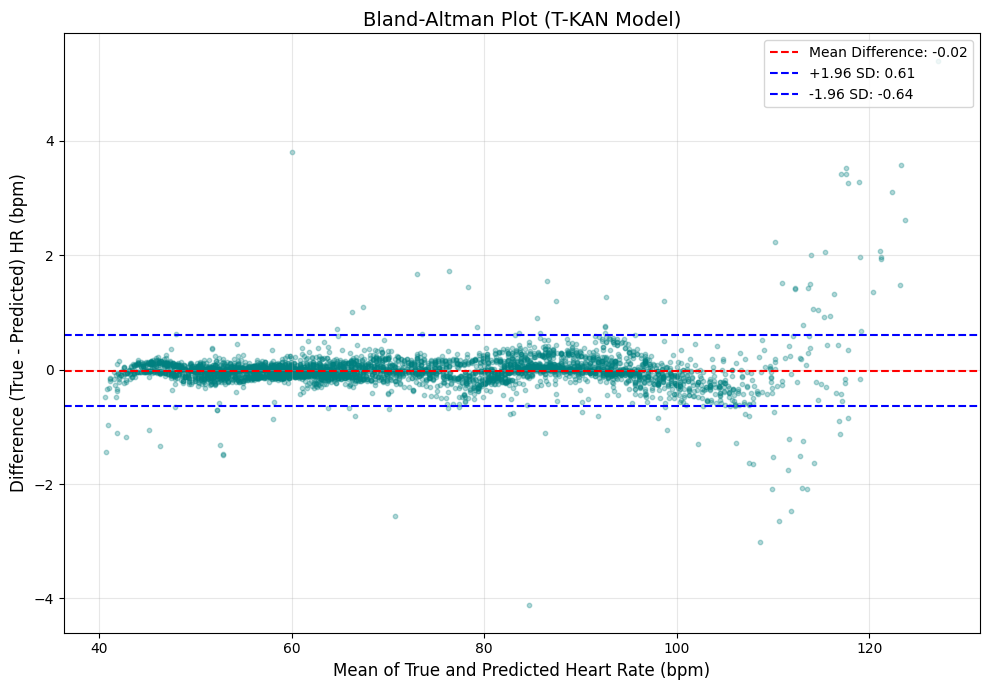

In [17]:
y_true_all = np.array(bland_altman_y_true)
y_pred_all = np.array(bland_altman_y_pred)

mean_vals = (y_true_all + y_pred_all) / 2
diff_vals = y_true_all - y_pred_all
md = np.mean(diff_vals)
sd = np.std(diff_vals, axis=0)

plt.figure(figsize=(10, 7))
plt.scatter(mean_vals, diff_vals, alpha=0.3, s=10, color='teal')
plt.axhline(md, color='red', linestyle='--', label=f'Mean Difference: {md:.2f}')
plt.axhline(md + 1.96 * sd, color='blue', linestyle='--', label=f'+1.96 SD: {md + 1.96*sd:.2f}')
plt.axhline(md - 1.96 * sd, color='blue', linestyle='--', label=f'-1.96 SD: {md - 1.96*sd:.2f}')

plt.xlabel('Mean of True and Predicted Heart Rate (bpm)', fontsize=12)
plt.ylabel('Difference (True - Predicted) HR (bpm)', fontsize=12)
plt.title('Bland-Altman Plot (T-KAN Model)', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("TKAN_bland_altman_New.png", dpi=600, bbox_inches="tight")
plt.show()

# Error Histogram (New)

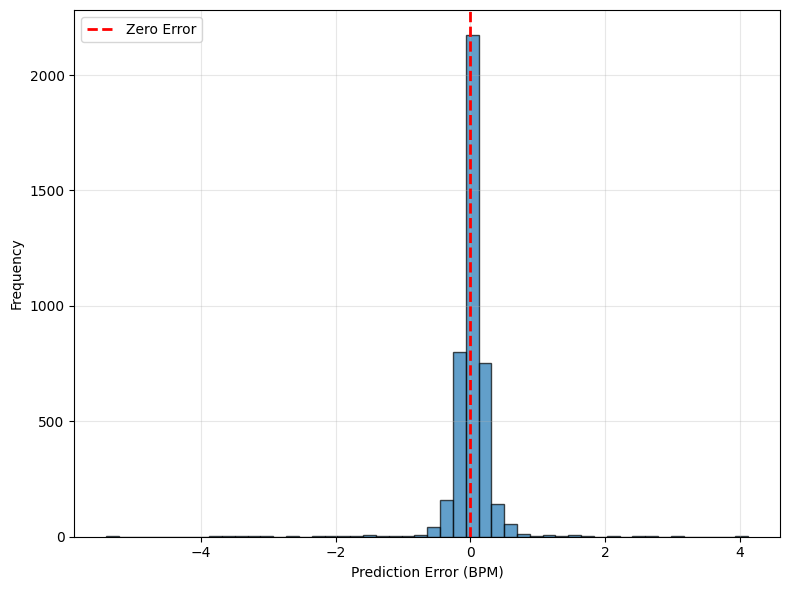

In [18]:
errors = y_pred_all - y_true_all

plt.figure(figsize=(8, 6))
# Using edgecolor to match the distinct bar outlines in the reference
plt.hist(errors, bins=50, color='tab:blue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')

plt.xlabel('Prediction Error (BPM)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("TKAN_error_histogram.png", dpi=600, bbox_inches="tight")
plt.show()